In [ ]:
# Download dataset from Kaggle
import kagglehub
import os

path = kagglehub.dataset_download("bhuviranga/mnist-digits")
print("Dataset path:", path)

100%|██████████| 9.16M/9.16M [00:00<00:00, 55.6MB/s]

Extracting files...


Dataset path: /root/.cache/kagglehub/datasets/bhuviranga/mnist-digits/versions/1


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

In [ ]:
# Automatically pick CSV file
files = os.listdir(path)
csv_file = [f for f in files if f.endswith('.csv')][0]

df = pd.read_csv(os.path.join(path, csv_file))

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (42000, 785)


,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


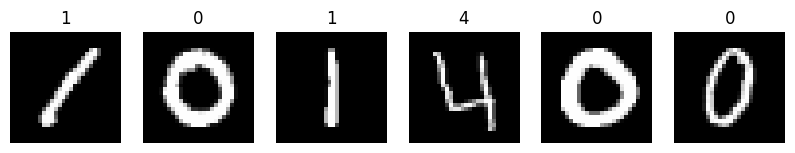

In [ ]:
X = df.iloc[:, 1:].values
y = df.iloc[:, 0].values

plt.figure(figsize=(10, 4))

for i in range(6):
    plt.subplot(1, 6, i + 1)
    img = X[i].reshape(28, 28)
    plt.imshow(img, cmap='gray')
    plt.title(y[i])
    plt.axis('off')

plt.show()

In [ ]:
# Normalize pixel values
X = X / 255.0

# Reshape for CNN (samples, height, width, channels)
X = X.reshape(-1, 28, 28, 1)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (33600, 28, 28, 1)
Test shape: (8400, 28, 28, 1)


In [ ]:
model = Sequential()

# Convolution Layer 1
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)))
model.add(MaxPooling2D(pool_size=(2,2)))

# Convolution Layer 2
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

# Flatten
model.add(Flatten())

# Fully Connected Layer
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.3))

# Output Layer (10 classes)
model.add(Dense(10, activation='softmax'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
840/840 ━━━━━━━━━━━━━━━━━━━━ 32s 36ms/step - accuracy: 0.9227 - loss: 0.2439 - val_accuracy: 0.9757 - val_loss: 0.0779
Epoch 2/10
840/840 ━━━━━━━━━━━━━━━━━━━━ 29s 34ms/step - accuracy: 0.9762 - loss: 0.0781 - val_accuracy: 0.9854 - val_loss: 0.0544
Epoch 3/10
840/840 ━━━━━━━━━━━━━━━━━━━━ 41s 34ms/step - accuracy: 0.9823 - loss: 0.0563 - val_accuracy: 0.9826 - val_loss: 0.0601
Epoch 4/10
840/840 ━━━━━━━━━━━━━━━━━━━━ 29s 35ms/step - accuracy: 0.9865 - loss: 0.0412 - val_accuracy: 0.9857 - val_loss: 0.0506
Epoch 5/10
840/840 ━━━━━━━━━━━━━━━━━━━━ 28s 34ms/step - accuracy: 0.9884 - loss: 0.0356 - val_accuracy: 0.9859 - val_loss: 0.0518
Epoch 6/10
840/840 ━━━━━━━━━━━━━━━━━━━━ 28s 33ms/step - accuracy: 0.9901 - loss: 0.0282 - val_accuracy: 0.9853 - val_loss: 0.0608
Epoch 7/10
840/840 ━━━━━━━━━━━━━━━━━━━━ 28s 33ms/step - accuracy: 0.9916 - loss: 0.0244 - val_accuracy: 0.9869 - val_loss: 0.0464
Epoch 8/10
840/840 ━━━━━━━━━━━━━━━━━━━━ 42s 34ms/step - accuracy: 0.9939 - loss: 0.0194 - 

In [ ]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred_classes))

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_classes))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_classes))

263/263 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step
Accuracy: 0.9876190476190476

Confusion Matrix:
[[810   0   1   0   0   0   3   1   0   1]
 [  0 906   2   0   0   0   0   0   1   0]
 [  0   2 838   0   4   0   0   0   2   0]
 [  0   1   4 926   0   0   0   1   5   0]
 [  2   0   0   0 833   0   2   0   0   2]
 [  0   0   0   4   3 688   3   0   1   3]
 [  3   1   0   0   1   2 777   0   1   0]
 [  0  10  14   0   2   0   0 864   0   3]
 [  0   2   1   0   4   1   0   1 824   2]
 [  2   1   0   0   3   1   0   0   1 830]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       816
           1       0.98      1.00      0.99       909
           2       0.97      0.99      0.98       846
           3       1.00      0.99      0.99       937
           4       0.98      0.99      0.99       839
           5       0.99      0.98      0.99       702
           6       0.99      0.99      0.99       785
           7       1.00

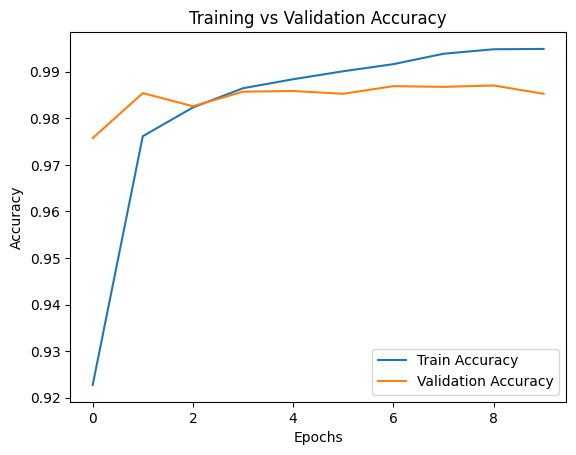

In [ ]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()